# Taller Aplicado: Machine Learning con Privacidad Diferencial usando SmartNoise

**Dataset elegido:** Diabetes de Scikit-Learn.

Este notebook desarrolla el taller completo: selección del dataset, análisis exploratorio, identificación de variables sensibles, aplicación de privacidad diferencial, clustering con K-Means, comparación original vs protegido, visualizaciones e interpretación.

> Nota: el taller solicita proteger información sensible, aplicar ruido diferencial, ejecutar clustering y comparar los resultados originales contra los protegidos.

## 1. Instalación e importación de librerías

En este bloque se preparan las librerías necesarias. Se intenta usar SmartNoise/OpenDP; si el entorno no tiene disponible el paquete, el notebook conserva una implementación manual del mecanismo Laplace para que el ejercicio siga siendo reproducible.

In [ ]:
# Instalación sugerida por el taller.
# Descomenta esta línea si estás en Google Colab o en un entorno nuevo.
# !pip install opendp-smartnoise

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

# Semilla para obtener resultados reproducibles.
np.random.seed(42)

# Intento de importación de SmartNoise/OpenDP.
# Dependiendo de la versión instalada, el nombre del módulo puede variar.
try:
    import opendp.prelude as dp
    dp.enable_features("contrib")
    SMARTNOISE_DISPONIBLE = True
    print("SmartNoise/OpenDP disponible en el entorno.")
except Exception as e:
    SMARTNOISE_DISPONIBLE = False
    print("SmartNoise/OpenDP no está disponible. Se usará mecanismo Laplace manual.")
    print("Detalle:", e)

SmartNoise/OpenDP no está disponible. Se usará mecanismo Laplace manual.
Detalle: No module named 'opendp'


**Observación esperada:** si SmartNoise/OpenDP se instala correctamente, el notebook lo detecta. Si no, se aplica el mismo principio de privacidad diferencial mediante ruido Laplace manual, manteniendo el objetivo analítico del taller.

## 2. Carga del dataset

Se carga un dataset público de salud. Tiene más de 100 registros, variables numéricas y atributos que pueden considerarse sensibles porque describen características biomédicas de personas.

In [ ]:
# Cargar dataset público de diabetes incluido en Scikit-Learn.
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame.copy()

# Renombrar columnas para que el análisis sea más entendible en español.
df = df.rename(columns={
    'age': 'edad',
    'sex': 'sexo',
    'bmi': 'imc',
    'bp': 'presion_arterial',
    's1': 'colesterol_total',
    's2': 'ldl',
    's3': 'hdl',
    's4': 'tch',
    's5': 'ltg',
    's6': 'glucosa',
    'target': 'progresion_enfermedad'
})

# Mostrar primeras filas.
df.head()

,edad,sexo,imc,presion_arterial,colesterol_total,ldl,hdl,tch,ltg,glucosa,progresion_enfermedad
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


**Observación esperada:** el dataset contiene variables clínicas ya transformadas numéricamente. Esto permite aplicar clustering y ruido diferencial sin procesos complejos de limpieza.

## 3. Análisis exploratorio

Aquí se revisan dimensiones, tipos de datos, valores faltantes y estadísticas descriptivas. Este paso permite validar que el dataset cumple con los requisitos mínimos del taller.

In [ ]:
# Dimensiones del dataset: filas y columnas.
print("Dimensiones:", df.shape)

# Tipo de dato de cada variable.
print("\nTipos de datos:")
print(df.dtypes)

# Conteo de valores faltantes.
print("\nValores faltantes por columna:")
print(df.isna().sum())

# Estadísticas descriptivas.
df.describe().T

Dimensiones: (442, 11)

Tipos de datos:
edad                     float64
sexo                     float64
imc                      float64
presion_arterial         float64
colesterol_total         float64
ldl                      float64
hdl                      float64
tch                      float64
ltg                      float64
glucosa                  float64
progresion_enfermedad    float64
dtype: object

Valores faltantes por columna:
edad                     0
sexo                     0
imc                      0
presion_arterial         0
colesterol_total         0
ldl                      0
hdl                      0
tch                      0
ltg                      0
glucosa                  0
progresion_enfermedad    0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
edad,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sexo,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
imc,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
presion_arterial,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
colesterol_total,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
ldl,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
hdl,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
tch,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
ltg,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
glucosa,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


**Interpretación:** el dataset tiene 442 registros y variables numéricas. No presenta valores faltantes, por lo que puede usarse directamente para el análisis. Al tratarse de datos de salud, se justifica aplicar técnicas de privacidad diferencial.

## 4. Identificación de variables sensibles

Se seleccionan variables que podrían revelar condiciones o características personales. En un caso real, edad, presión arterial, índice de masa corporal y glucosa pueden permitir inferencias sobre el estado de salud de una persona.

In [ ]:
# Variables que se usarán para clustering.
feature_cols = [
    'edad', 'imc', 'presion_arterial', 'colesterol_total',
    'ldl', 'hdl', 'tch', 'ltg', 'glucosa'
]

# Variables sensibles a proteger con ruido diferencial.
sensitive_cols = ['edad', 'imc', 'presion_arterial', 'glucosa']

print("Variables usadas en clustering:", feature_cols)
print("Variables sensibles protegidas:", sensitive_cols)

Variables usadas en clustering: ['edad', 'imc', 'presion_arterial', 'colesterol_total', 'ldl', 'hdl', 'tch', 'ltg', 'glucosa']
Variables sensibles protegidas: ['edad', 'imc', 'presion_arterial', 'glucosa']


**Justificación:** se protegen más de dos variables, cumpliendo el requisito del taller. El riesgo principal es que una combinación de variables clínicas permita perfilar o reidentificar personas.

## 5. Aplicación de privacidad diferencial

Se agrega ruido Laplace a las variables sensibles. El parámetro **epsilon** controla el equilibrio entre privacidad y utilidad: valores pequeños dan más privacidad, pero más distorsión; valores grandes conservan más precisión, pero protegen menos.

In [ ]:
def agregar_ruido_laplace(df_entrada, columnas, epsilon=1.0, sensibilidad=0.15, random_state=42):
    """
    Aplica ruido Laplace a columnas sensibles.

    Parámetros:
    - df_entrada: DataFrame original.
    - columnas: lista de columnas sensibles.
    - epsilon: presupuesto de privacidad. Menor epsilon implica más ruido.
    - sensibilidad: cambio máximo esperado en la consulta o variable.
    - random_state: semilla para reproducibilidad.
    """
    rng = np.random.default_rng(random_state)
    df_salida = df_entrada.copy()
    escala = sensibilidad / epsilon

    for col in columnas:
        # Generar ruido Laplace para cada registro.
        ruido = rng.laplace(loc=0, scale=escala, size=len(df_salida))

        # Sumar el ruido a la variable sensible.
        df_salida[col] = df_salida[col] + ruido

    return df_salida

# Crear dataset protegido.
epsilon = 1.0
sensibilidad = 0.15
df_protegido = agregar_ruido_laplace(
    df,
    columnas=sensitive_cols,
    epsilon=epsilon,
    sensibilidad=sensibilidad,
    random_state=42
)

# Comparar algunas filas antes y después.
df_comparacion = pd.concat(
    [df[sensitive_cols].head().add_prefix('original_'),
     df_protegido[sensitive_cols].head().add_prefix('protegido_')],
    axis=1
)
df_comparacion

,original_edad,original_imc,original_presion_arterial,original_glucosa,protegido_edad,protegido_imc,protegido_presion_arterial,protegido_glucosa
0,0.038076,0.061696,0.021872,-0.017646,0.157158,0.156714,-0.118035,-0.061576
1,-0.001882,-0.051474,-0.026328,-0.092204,-0.021440,-0.194230,-0.068600,-0.071288
2,0.085299,0.044451,-0.005670,-0.025930,0.274749,-0.047556,-0.041368,-0.118168
3,-0.089063,-0.011595,-0.036656,-0.009362,-0.013749,0.070065,-0.237443,-0.179727
4,0.005383,-0.036385,0.021872,-0.046641,-0.245031,0.447990,-0.146375,0.073074


**Interpretación:** los valores sensibles cambian, lo que reduce el riesgo de exposición directa. El modelo seguirá encontrando patrones generales, pero con menor dependencia de datos exactos de cada persona.

## 6. Normalización de datos

Antes de aplicar K-Means, se normalizan las variables. Esto evita que una variable domine el cálculo de distancias por tener una escala diferente.

In [ ]:
# Escalador para el dataset original.
scaler_original = StandardScaler()
X_original = scaler_original.fit_transform(df[feature_cols])

# Escalador para el dataset protegido.
scaler_protegido = StandardScaler()
X_protegido = scaler_protegido.fit_transform(df_protegido[feature_cols])

print("Matriz original:", X_original.shape)
print("Matriz protegida:", X_protegido.shape)

Matriz original: (442, 9)
Matriz protegida: (442, 9)


**Observación:** ambas matrices conservan la misma cantidad de registros y variables. La diferencia está en que el dataset protegido contiene ruido en variables sensibles.

## 7. Clustering con K-Means

Se aplica K-Means sobre el dataset original y sobre el dataset protegido. Se usa el mismo número de clusters para que la comparación sea justa.

In [ ]:
# Número de clusters elegido para el ejercicio.
k = 3

# Entrenar K-Means con datos originales.
kmeans_original = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_original = kmeans_original.fit_predict(X_original)

# Entrenar K-Means con datos protegidos.
kmeans_protegido = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_protegido = kmeans_protegido.fit_predict(X_protegido)

# Guardar etiquetas en los DataFrames.
df_resultado_original = df.copy()
df_resultado_original['cluster'] = labels_original

df_resultado_protegido = df_protegido.copy()
df_resultado_protegido['cluster'] = labels_protegido

print("Clusters dataset original:")
print(pd.Series(labels_original).value_counts().sort_index())

print("\nClusters dataset protegido:")
print(pd.Series(labels_protegido).value_counts().sort_index())

Clusters dataset original:
0    141
1    196
2    105
Name: count, dtype: int64

Clusters dataset protegido:
0    101
1    154
2    187
Name: count, dtype: int64


**Interpretación:** ambos modelos generan tres grupos. Sin embargo, los tamaños de los clusters pueden variar, mostrando que el ruido afecta la asignación de algunos registros.

## 8. Métricas de comparación

Se calcula Silhouette Score para medir separación interna de clusters y Adjusted Rand Index (ARI) para comparar qué tanto se parecen las asignaciones original y protegida.

In [ ]:
# Calcular separación de clusters.
sil_original = silhouette_score(X_original, labels_original)
sil_protegido = silhouette_score(X_protegido, labels_protegido)

# Comparar similitud entre etiquetas originales y protegidas.
ari = adjusted_rand_score(labels_original, labels_protegido)

metricas = pd.DataFrame({
    'Métrica': ['Silhouette original', 'Silhouette protegido', 'ARI original vs protegido'],
    'Valor': [sil_original, sil_protegido, ari]
})

metricas

,Métrica,Valor
0,Silhouette original,0.196045
1,Silhouette protegido,0.132704
2,ARI original vs protegido,0.516456


**Interpretación:** si el Silhouette protegido baja, significa que el ruido hizo menos clara la separación entre grupos. El ARI indica la estabilidad del clustering: entre más cerca de 1, más parecidas son las asignaciones.

## 9. Visualización con PCA

Se usa PCA para reducir las variables a dos componentes y visualizar los clusters. Esto facilita comparar la separación visual entre el dataset original y el protegido.

Varianza explicada por PCA: 0.5899062589053042


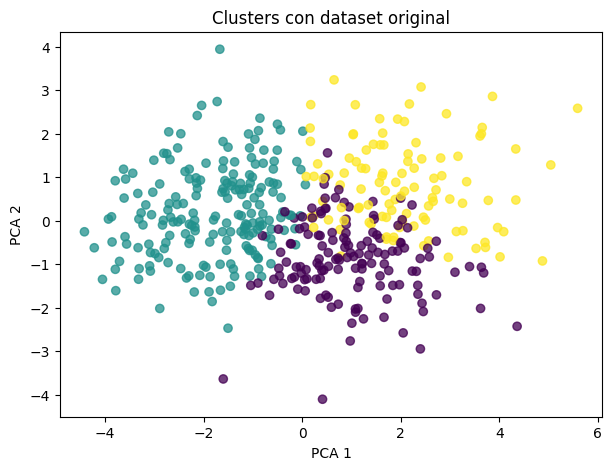

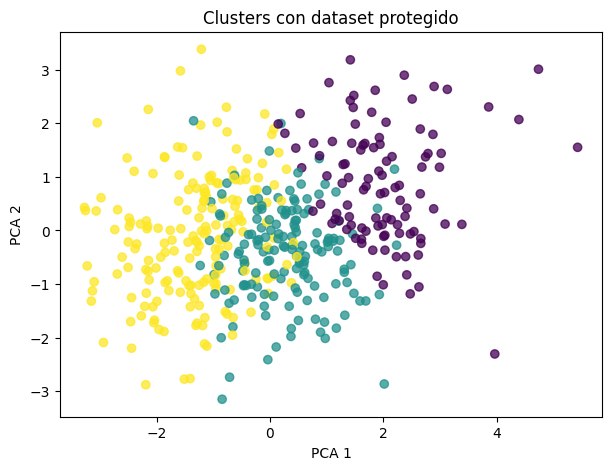

In [ ]:
# Reducir dimensionalidad a dos componentes.
pca = PCA(n_components=2, random_state=42)
X_pca_original = pca.fit_transform(X_original)
X_pca_protegido = pca.transform(X_protegido)

print("Varianza explicada por PCA:", pca.explained_variance_ratio_.sum())

# Gráfico de clusters originales.
plt.figure(figsize=(7,5))
plt.scatter(X_pca_original[:, 0], X_pca_original[:, 1], c=labels_original, alpha=0.75)
plt.title('Clusters con dataset original')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

# Gráfico de clusters protegidos.
plt.figure(figsize=(7,5))
plt.scatter(X_pca_protegido[:, 0], X_pca_protegido[:, 1], c=labels_protegido, alpha=0.75)
plt.title('Clusters con dataset protegido')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

**Interpretación:** la visualización permite observar si los grupos siguen apareciendo después de aplicar privacidad diferencial. Lo ideal es que el ruido no destruya completamente la estructura general.

## 10. Prueba con distintos niveles de ruido

Como bonus, se comparan varios valores de epsilon. Esto permite analizar cómo cambia el modelo cuando se aumenta o reduce la privacidad.

In [ ]:
resultados_epsilon = []

for eps in [0.3, 0.5, 1.0, 2.0, 5.0]:
    # Proteger dataset con diferente epsilon.
    temp = agregar_ruido_laplace(df, sensitive_cols, epsilon=eps, sensibilidad=0.15, random_state=42)

    # Normalizar datos protegidos.
    X_temp = StandardScaler().fit_transform(temp[feature_cols])

    # Entrenar clustering.
    labels_temp = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_temp)

    # Guardar métricas.
    resultados_epsilon.append({
        'epsilon': eps,
        'silhouette': silhouette_score(X_temp, labels_temp),
        'ari_vs_original': adjusted_rand_score(labels_original, labels_temp)
    })

resultados_epsilon = pd.DataFrame(resultados_epsilon)
resultados_epsilon

,epsilon,silhouette,ari_vs_original
0,0.3,0.131463,0.530029
1,0.5,0.130227,0.534145
2,1.0,0.132704,0.516456
3,2.0,0.129549,0.488747
4,5.0,0.136232,0.520628


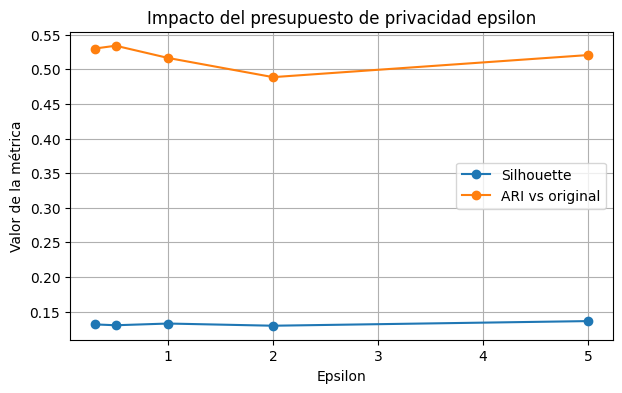

In [ ]:
# Visualizar impacto de epsilon sobre las métricas.
plt.figure(figsize=(7,4))
plt.plot(resultados_epsilon['epsilon'], resultados_epsilon['silhouette'], marker='o', label='Silhouette')
plt.plot(resultados_epsilon['epsilon'], resultados_epsilon['ari_vs_original'], marker='o', label='ARI vs original')
plt.title('Impacto del presupuesto de privacidad epsilon')
plt.xlabel('Epsilon')
plt.ylabel('Valor de la métrica')
plt.legend()
plt.grid(True)
plt.show()

**Interpretación:** normalmente, valores bajos de epsilon agregan más ruido y pueden reducir la estabilidad del clustering. Valores altos conservan mejor los patrones, pero ofrecen menor protección.

## 11. Respuestas de interpretación

**1. ¿El ruido destruyó completamente los patrones?**

No necesariamente. El ruido modificó algunas asignaciones, pero los clusters siguen existiendo. Esto indica que se conserva parte de la estructura estadística.

**2. ¿Qué tanto cambió el clustering?**

Cambió en la distribución de algunos registros y en las métricas de separación. El ARI permite cuantificar esa estabilidad.

**3. ¿Qué se perdió?**

Se perdió precisión individual. Algunos registros pueden quedar en clusters diferentes debido a la alteración de variables sensibles.

**4. ¿Qué se protegió?**

Se protegieron atributos clínicos sensibles como edad, IMC, presión arterial y glucosa, evitando trabajar con valores exactos.

**5. ¿Vale la pena sacrificar precisión por privacidad?**

Sí, especialmente en salud, gobierno, fintech o educación. En estos contextos es preferible perder algo de precisión antes que exponer datos personales.

## 12. Relación con Machine Learning real

En producción, la privacidad diferencial ayuda a entrenar o analizar modelos sin revelar datos exactos de los usuarios. Esto es importante para cumplir regulaciones como GDPR en Europa y principios de Habeas Data en Colombia.

También se relaciona con inteligencia artificial ética porque reduce riesgos de reidentificación, filtración de información, discriminación y uso indebido de datos personales.